In [1]:
import utils
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
basedir = "../5_task_transfer"

In [17]:
df = utils.subset_data(
    basedir=basedir,
    index={
        # "model.from_pretrained": lambda x: x is not None,
        "dataset.concurrent_reg": lambda x: x == 5,
    },
)
df.sample(5)

,Unnamed: 0,epoch,run_id,_runtime,best_val_acc,best_val_epoch,best_val_loss,epoch_step,_step,cumAUC,...,heldout_items,concurrent_reg,same_diff_prob,concurrent_items,role_n_congruence,heldout_items_per_reg,create_dataset_and_exit,local_split_set_control,global_split_set_control,pretraining_condition
539,539,53,twilight-sweep-1,12446.952058,0.0,52.0,0.638471,0.0,21094,31.905250,...,0,5,0.5,4,0,15,False,NaN,NaN,NA
206,206,20,neat-sweep-4,2773.608959,0.0,16.0,0.030634,0.0,7960,15.921935,...,0,5,0.5,4,0,15,False,NaN,NaN,NA
213,213,21,firm-sweep-1,5560.903891,0.0,7.0,0.623186,0.0,8358,13.378370,...,0,5,0.5,4,0,15,False,NaN,NaN,N-BACK
329,329,32,twilight-sweep-1,7516.593271,0.0,31.0,0.643262,0.0,12736,19.051015,...,0,5,0.5,4,0,15,False,NaN,NaN,NA
381,381,38,genial-sweep-6,6548.517925,0.0,35.0,0.003965,0.0,15125,37.443360,...,0,5,0.5,4,0,15,False,NaN,NaN,N-BACK


In [12]:
td_prob_info = utils.extract_sweep_properties(
    utils.gather_sweeps(basedir), ["dataset.td_prob"]
)
[*td_prob_info.items()][0]

('7fpiixi7', {'dataset.td_prob': 0})

In [13]:
def get_pretraining_condition(row):
    this_sweep_id = row["sweep_id"]
    this_pretraining = row["from_pretrained"]
    if isinstance(this_pretraining, str):
        pretraining_sweep_id = this_pretraining.split("/")[1]
        return (
            "REF-BACK"
            if td_prob_info[pretraining_sweep_id]["dataset.td_prob"] == 0
            else "N-BACK"
        )
    return "NA"


# map td_prob_info to `df` as a new column called 'pretraining_condition'
df["pretraining_condition"] = df.apply(
    get_pretraining_condition,
    axis=1,
)

df.loc[df["from_pretrained"] == None]["pretraining_condition"] = "NA"

<Axes: xlabel='epoch', ylabel='eval_acc'>

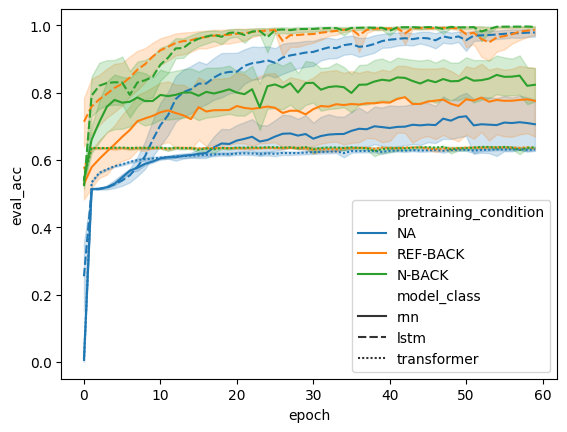

In [14]:
sns.lineplot(
    df, x="epoch", y="eval_acc", hue="pretraining_condition", style="model_class"
)

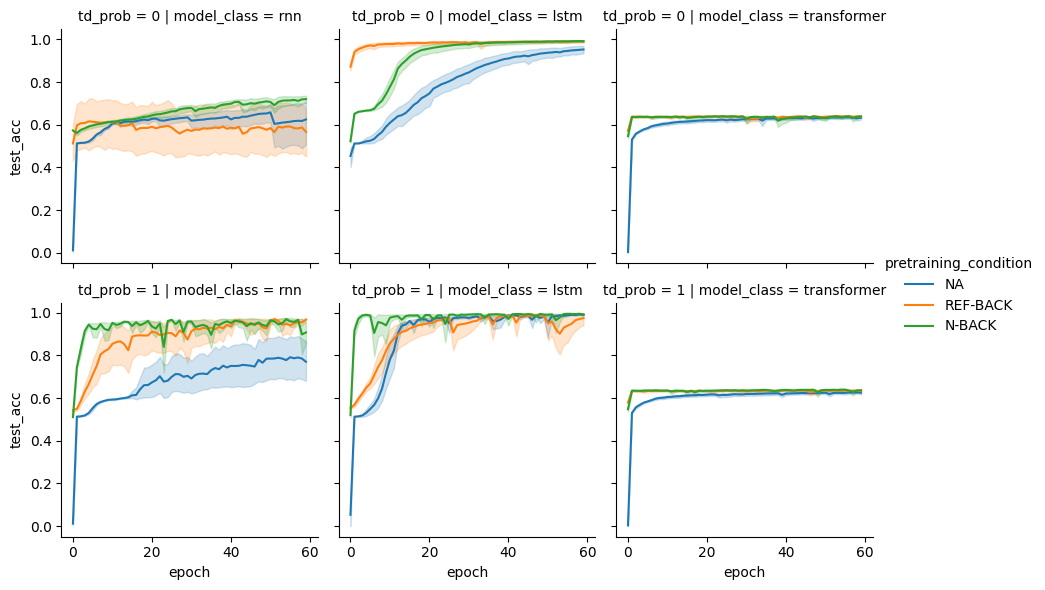

In [15]:
g = sns.FacetGrid(
    df,
    col="model_class",
    row="td_prob",
    hue="pretraining_condition",
)
g.map(
    sns.lineplot,
    "epoch",
    "test_acc",
)

g.add_legend()